# Libraries
Numpy - working with arrays and mathematical operations on arrays
Pandas - data manipulation and analysis. built on top of numpy
matplotlib - data visualization. built on top of numpy
sklearn - for machine learning modeling. both supervised and unsupervised learning. provides tools for model fitting, data preprocessing, model selection, model evaluation etc. built on top of pandas, numpy and matplotlib


We can load the CSV file by using the read_csv() function from pandas. It reads a CSV file into a DataFrame. A DataFrame is a two-dimensional data structure in which data is aligned in a tabular format in rows and columns.
We generally import pandas as an alias pd.




In [3]:
import pandas as pd
## load data ##
housing = pd.read_csv("/cxldata/datasets/project/housing/housing.csv")

## explore data ##
housing.head() # top 5 rows by default
print(housing.head(10)) # top 10 rows
housing.info() # concise summary of dataset

housing['ocean_proximity'].value_counts() # displays all the categories with their count
# housing.value_counts()

housing.describe() # statistical description of dataset. numerical attributes by default
housing.describe(include='all') # include all attributes

# std - how spread out the data values are from the mean (average).
# Variance = (sum((DataValue - mean)**2))/N
# std = sqrt(Variance)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   
5    -122.25     37.85                52.0        919.0           213.0   
6    -122.25     37.84                52.0       2535.0           489.0   
7    -122.25     37.84                52.0       3104.0           687.0   
8    -122.26     37.84                42.0       2555.0           665.0   
9    -122.25     37.84                52.0       3549.0           707.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0   

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1H OCEAN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9136
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,NaN
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,NaN
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,NaN
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,NaN
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,NaN
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,NaN


array([[<AxesSubplot:title={'center':'longitude'}>,
        <AxesSubplot:title={'center':'latitude'}>,
        <AxesSubplot:title={'center':'housing_median_age'}>],
       [<AxesSubplot:title={'center':'total_rooms'}>,
        <AxesSubplot:title={'center':'total_bedrooms'}>,
        <AxesSubplot:title={'center':'population'}>],
       [<AxesSubplot:title={'center':'households'}>,
        <AxesSubplot:title={'center':'median_income'}>,
        <AxesSubplot:title={'center':'median_house_value'}>]],
      dtype=object)

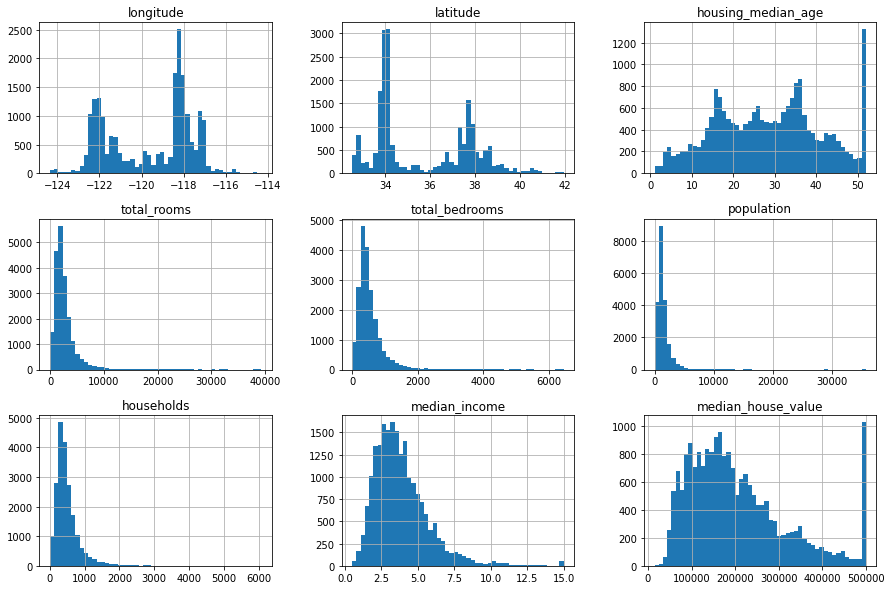

In [4]:
# histogram - count of instances belonging to each category of a categorical attribute
import matplotlib.pyplot as plt

%matplotlib inline  
# plots and graphs are shown next to the code in our notebook and are stored within the notebook. Otherwise, the plots and graphs are displayed in a separate window and not within our notebook.
housing.hist(figsize=(15,10), bins=50)


# Capping : limit an attribute so that its value doesn't go above a certain limit
# median_house_value is capped at 500000 and hence all the houses with a value of more than 500000 are given the same value.
# also notice that attributes have varying scales.

array([[<AxesSubplot:title={'center':'longitude'}>,
        <AxesSubplot:title={'center':'latitude'}>,
        <AxesSubplot:title={'center':'housing_median_age'}>],
       [<AxesSubplot:title={'center':'total_rooms'}>,
        <AxesSubplot:title={'center':'total_bedrooms'}>,
        <AxesSubplot:title={'center':'population'}>],
       [<AxesSubplot:title={'center':'households'}>,
        <AxesSubplot:title={'center':'median_income'}>,
        <AxesSubplot:title={'center':'median_house_value'}>]],
      dtype=object)

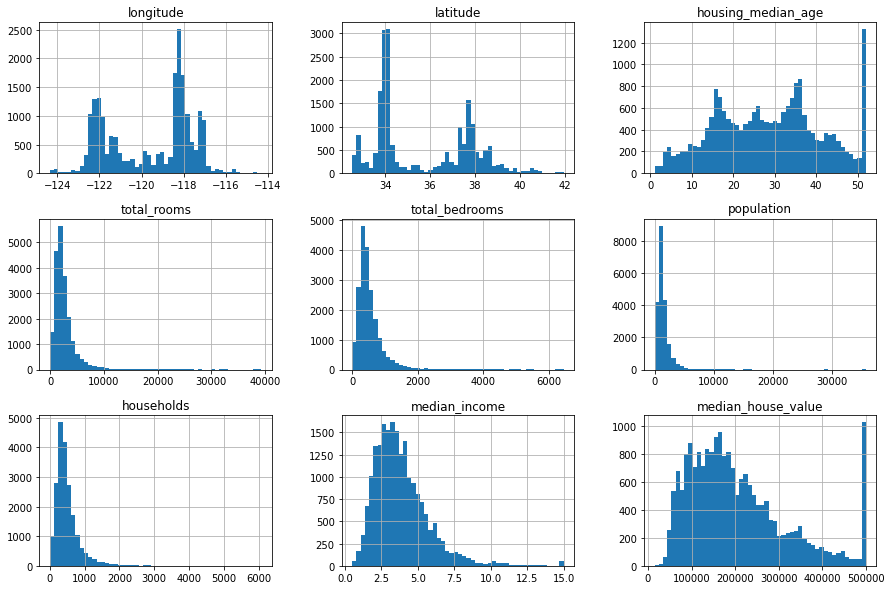

In [5]:
%matplotlib inline
housing.hist(figsize=(15,10), bins=50)

In [6]:
# data snooping bias : create test set before data visualization, else there will be chances that we will be studying the patterns/relations/outliers according to which we will decide the model. Thus model performs good on test data, but not for real-world data
# stratified sampling : 65:35 is the ratio in real world. so model also keeps this distribution smong different strata
# random split will not achieve real-world distribution
# random_state = <some_number> => model should split the same test data always when model runs, else data leakage can happen

In [7]:
income_cat = pd.cut(housing['median_income'], bins = [0, 1.5, 3, 4.5, 6, 16], labels = [1, 2, 3, 4, 5])
income_cat.head()

0    5
1    5
2    5
3    4
4    3
Name: median_income, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

In [8]:
import sklearn
from sklearn.model_selection import StratifiedShuffleSplit
# parameters
# n_splits -> how many different validation & training sets you will create
# test_size -> 0.2 means 20% test set
# random_state = 42 -> no matter how many times we run our code, the training and test set will contain the same instances on every run.
split_object = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state = 42)
gen_obj = split_object.split(housing, income_cat) # returns a generator object, which contains indexes of instances belonging to the training and testing dataset.
train_ind, test_ind = next(gen_obj) # extract the indices from the generator object.

strat_train_set = housing.loc[train_ind]
strat_test_set = housing.loc[test_ind]

<AxesSubplot:xlabel='latitude', ylabel='longitude'>

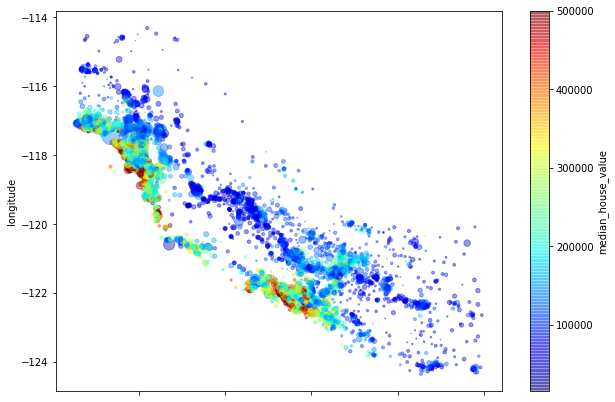

In [9]:
# EDA

train_copy = strat_train_set.copy()

# DataFrame.plot()
# kind -> bar/hist/scatter
# x, y -> attribute in x and y axes
# alpha -> opacity ranges from 0 to 1
# s -> marker/circle size
# c -> marker color
# cmap -> colormap instance to be used to represent a different range of the attribute specified to the c parameter with different colors.
# colorbar -> If true, it plots the colorbar
# figsize -> size of the plot

train_copy.plot(kind='scatter', x='latitude', y='longitude', alpha=0.4, s=train_copy["population"]/100, c='median_house_value', cmap=plt.get_cmap("jet"), colorbar=True, figsize=(10,7))

In [10]:
# correlation -> finds linear relation of attributes
# correlation coefficient -> measure of relation of attributes
# 1 or -1-> perfect +ve or -ve correlation, 0-> no correlation
# correlation coeffiecient ranges [-1,1]
# correlation matrix -> symmetrical matrix showing correlation coefficient attributes
# Correlation close to zero means there is no linear relationship, but can have non-linear relationship 

train_copy.corr()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924478,-0.105848,0.048871,0.076598,0.108030,0.063070,-0.019583,-0.047432
latitude,-0.924478,1.000000,0.005766,-0.039184,-0.072419,-0.115222,-0.077647,-0.075205,-0.142724
housing_median_age,-0.105848,0.005766,1.000000,-0.364509,-0.325047,-0.298710,-0.306428,-0.111360,0.114110
total_rooms,0.048871,-0.039184,-0.364509,1.000000,0.929379,0.855109,0.918392,0.200087,0.135097
total_bedrooms,0.076598,-0.072419,-0.325047,0.929379,1.000000,0.876320,0.980170,-0.009740,0.047689
population,0.108030,-0.115222,-0.298710,0.855109,0.876320,1.000000,0.904637,0.002380,-0.026920
households,0.063070,-0.077647,-0.306428,0.918392,0.980170,0.904637,1.000000,0.010781,0.064506
median_income,-0.019583,-0.075205,-0.111360,0.200087,-0.009740,0.002380,0.010781,1.000000,0.687160
median_house_value,-0.047432,-0.142724,0.114110,0.135097,0.047689,-0.026920,0.064506,0.687160,1.000000


array([[<AxesSubplot:xlabel='median_house_value', ylabel='median_house_value'>,
        <AxesSubplot:xlabel='median_income', ylabel='median_house_value'>,
        <AxesSubplot:xlabel='latitude', ylabel='median_house_value'>,
        <AxesSubplot:xlabel='total_rooms', ylabel='median_house_value'>,
        <AxesSubplot:xlabel='housing_median_age', ylabel='median_house_value'>],
       [<AxesSubplot:xlabel='median_house_value', ylabel='median_income'>,
        <AxesSubplot:xlabel='median_income', ylabel='median_income'>,
        <AxesSubplot:xlabel='latitude', ylabel='median_income'>,
        <AxesSubplot:xlabel='total_rooms', ylabel='median_income'>,
        <AxesSubplot:xlabel='housing_median_age', ylabel='median_income'>],
       [<AxesSubplot:xlabel='median_house_value', ylabel='latitude'>,
        <AxesSubplot:xlabel='median_income', ylabel='latitude'>,
        <AxesSubplot:xlabel='latitude', ylabel='latitude'>,
        <AxesSubplot:xlabel='total_rooms', ylabel='latitude'>,
        <

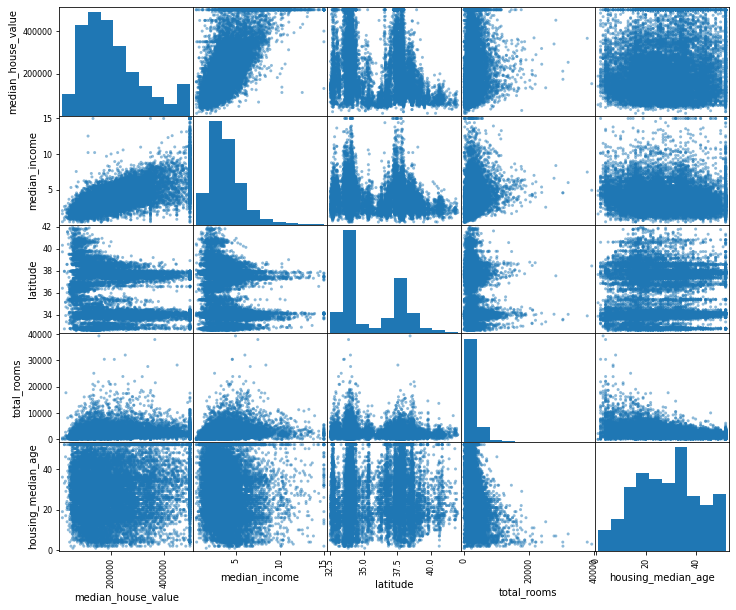

In [11]:
#scatter_matrix() visualize correlation
# It plots every numerical attribute against every other numerical attribute. In the case of an attribute against itself, instead of plotting the scatter plot, scatter_matrix() plots the histogram of the attribute.

pd.plotting.scatter_matrix(train_copy[['median_house_value','median_income','latitude', 'total_rooms', 'housing_median_age']], figsize=(12,10))

In [12]:
train_copy["rooms_per_household"] = train_copy["total_rooms"]/train_copy["households"]
train_copy["bedrooms_per_room"] = train_copy["total_bedrooms"]/train_copy["total_rooms"]
train_copy["population_per_household"] = train_copy["population"]/train_copy["households"]

In [13]:
train_copy.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
longitude,1.000000,-0.924478,-0.105848,0.048871,0.076598,0.108030,0.063070,-0.019583,-0.047432,-0.028345,0.095603,-0.000410
latitude,-0.924478,1.000000,0.005766,-0.039184,-0.072419,-0.115222,-0.077647,-0.075205,-0.142724,0.107621,-0.116884,0.005420
housing_median_age,-0.105848,0.005766,1.000000,-0.364509,-0.325047,-0.298710,-0.306428,-0.111360,0.114110,-0.147186,0.136788,0.015031
total_rooms,0.048871,-0.039184,-0.364509,1.000000,0.929379,0.855109,0.918392,0.200087,0.135097,0.127519,-0.192606,-0.024810
total_bedrooms,0.076598,-0.072419,-0.325047,0.929379,1.000000,0.876320,0.980170,-0.009740,0.047689,0.000377,0.086960,-0.028370
population,0.108030,-0.115222,-0.298710,0.855109,0.876320,1.000000,0.904637,0.002380,-0.026920,-0.074692,0.037778,0.076225
households,0.063070,-0.077647,-0.306428,0.918392,0.980170,0.904637,1.000000,0.010781,0.064506,-0.083009,0.067162,-0.027416
median_income,-0.019583,-0.075205,-0.111360,0.200087,-0.009740,0.002380,0.010781,1.000000,0.687160,0.311563,-0.624674,0.021822
median_house_value,-0.047432,-0.142724,0.114110,0.135097,0.047689,-0.026920,0.064506,0.687160,1.000000,0.146285,-0.259984,-0.021985
rooms_per_household,-0.028345,0.107621,-0.147186,0.127519,0.000377,-0.074692,-0.083009,0.311563,0.146285,1.000000,-0.398546,-0.005314


In [14]:
train_data = strat_train_set.drop(['median_house_value'], axis=1)
# axis=0 -> remove row
# axis=1 -> remove column
housing_labels = strat_train_set['median_house_value'].copy()

In [15]:
# Handling Missing Values
# -> Drop the rows/columns
# -> Set to some value - 0/mean/median/mode/constant
# median (middle value) -> not affected by outliers
# mode -> for categorical/text attributes

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
#housing_num = train_data.drop()
columns = train_data.columns
for column in columns:
    if train_data[column].dtype != 'float64':
        housing_num = train_data.drop(column, axis=1)
imputer.fit(housing_num)
out = imputer.transform(housing_num)
housing_tr = pd.DataFrame(out, columns=housing_num.columns)

In [16]:
# One Hot Encoding : 
# - encoding categorical variables
# - each attribute represented by vectors

from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
one_hot = encoder.fit_transform(train_data[['ocean_proximity']])

In [17]:
# Custom TRansformers : for data transformations
# Pipeline : execute all transformation steps in sequential order
# As transformers use in ML alot, it should work seamlessly with sklearn functionalities. So it needs to implement 3 methods - fit, transorm & fir_transform
# TransformerMixin -> baseclass for fit_transform(). gives you fit_transform()
# BaseEstimator -> makes it compatible with Scikit-learn. base class having methods get_params() and set_params()

from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
    
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        rooms_per_household = X[:, 3] / X[:, 6]
        population_per_household = X[:, 5] / X[:, 6]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, 4] / X[:, 3]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]
       
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room =False)
housing_extra_attribs = attr_adder.transform(train_data.values)

In [18]:
# Scaling
# scaling on target variable/label is not required
# 1. Min-Max Scaling (Normalization):
#    - Normalized data will be in range of [0,1] 
#    - good for NN
#    - normalized value = (Original value - min)/(max-min)
# 2. Standardization:
#    - how many std away the value from the mean
#    - zero mean and unit variance (mean=0 & std=1)
#    - may result in large range 
#    - less affected by outlier 
#    - good for SVM, Logistic regression

# MinMaxScaler -> for Min-Max scaling
# StandardScaler -> standardization
 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(housing_num)

In [19]:
# Transformation Pipelines
# syntax: Pipeline(steps) where steps is tuple of (name, estimator)
# name -> object name we decided for estimator(__ (doublr underscore) not allowed ) 
# estimator -> any object that learns from data, 'classification/regression/clustering algorithm/transformer' that extracts/filters useful features from raw data
# last estimator in a pipeline -> be or not be a transformer
# all other estimators must be a transformer (have fit_transorm() method)

from sklearn.pipeline import Pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("attribs_adder", CombinedAttributesAdder()),
    ("std_scaler", StandardScaler())
])

housing_num_tr = num_pipeline.fit_transform(housing_num)

# When we call the fit() method on our pipeline instance, it calls the method fit_transform() on all estimators, passing the output of one as input to the next in a sequential order until the last estimator. 
# On the last estimator, it calls the fit() method. 
# But when we use the fit_transform() method on our pipeline, then on the last estimator too fit_transform() is called instead of the fit() method. 
# So, if our last estimator is a transformer, it is advised to use the fit_transform() method.

In [20]:
# ColumnTransformer
# To handle both categorical and numerical attributes by applying the appropriate transformation to each attribute
# ColumnTransformer works only with transformers.
# So even the last estimator in the pipeline must be a transformer.

from sklearn.compose import ColumnTransformer
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, list(housing_num)),
    ('cat', OneHotEncoder(), ["ocean_proximity"])
])

housing_prepared = full_pipeline.fit_transform(train_data)

In [21]:
# attributes <=> features <=> predictors
# labels <=> target variables

# Linear Regression model
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)
predictions = lin_reg.predict(housing_prepared)

In [23]:
# Measuring Performance
# metric : RMSE, measures mean squared error regression loss
# mean_squared_error(y_actual, y_predict, squared=False)
# To make it function like RMSE, we have to specify the parameter squared to False. 
# By default its value is True.

from sklearn.metrics import mean_squared_error
lin_rmse = mean_squared_error(housing_labels, predictions, squared=False)
print(lin_rmse) # 68628.19819848923

# Underfitting : 
#  - does not capture the underlying trend of the data
#  - fails to perform well on our training dataset
#  - means either the features do not provide enough information to make good predictions, or that the model is not powerful enough
#  - Solution
#       - Add more features to the dataset
#       - Reduce the constraints on the model
#       - Try a more complex model

68628.19819848922


In [24]:
# DecisionTreeRegressor - to detect non-linear trends in our data
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)
predictions = tree_reg.predict(housing_prepared)

tree_rmse = mean_squared_error(housing_labels, predictions, squared=False)
print(tree_rmse) # 0.0

# Overfitting
# - model performs very well on our training data but fails to perform well on our testing data or the real world
# - memorizes the training data so well that it predicts the value very close to the actual values
# - even finds patterns in the noise and hence fails to perform well when some other data is given
# - SOlution - Cross validation
#     - separate some part of training data and use it as validation data. Then train the model again on leftover training data and evaluate model on validation data

# Note: we can't be sure that it's always overfitting because this scenario can also arise due to some other problems such as data mismatch on training and test set. It means the test set contains different type of data(having different distribution) which was not there in the training data. 

# stochastic nature of the algorithm: 
# In Scikit-learn Random Forest:
#    - random subset of data is selected (bootstrapping)
#    - random subset of features is selected at each split
# So every run can build slightly different trees.That randomness is its stochastic nature.



0.0


In [25]:
# Cross Validation
# paraeters:
# - scoring -> evaluation metric that we specify
# -  cv ->  value of k in the k-fold

# Scikit-learn cross-validation uses utility scores where higher is better. Since error metrics like MSE are lower-is-better, Scikit-learn returns them as negative values so they follow the same higher-is-better convention.
# Cost function measures error (MSE, RMSE, MAE)
# Utility function measures goodness/performance (Accuracy, R^2 Score, F1 Score)

from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg, housing_prepared, housing_labels, scoring='neg_root_mean_squared_error', cv=10)
scores = abs(scores)
print(scores)

[69757.17718836 64686.20050112 71108.81110492 69515.98409182
 70603.02791825 74458.56728869 69958.74650997 72693.22464433
 75647.02231911 69283.09159283]


In [27]:
# RandomForestRegressor 

# trains several decision trees on random subsets of the features 
# and averages out all their values while prediction 
# hence reducing overfitting by a much greater extent.

from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)
predictions = forest_reg.predict(housing_prepared)
forest_rmse = mean_squared_error(housing_labels, predictions, squared=False)
scores = cross_val_score(forest_reg, housing_prepared, housing_labels, scoring='neg_root_mean_squared_error', cv=10)
scores = abs(scores)
print(forest_rmse)
print(scores)

In [36]:
# GridSearchCV
# hyper parameter tuning (different possible combinations of given values)
# using cross-validation

# parameters:
# - param_grid - dictionary of hyperparameter names as keys and their list of values we want to try out as values

from sklearn.model_selection import GridSearchCV
reg_forest = RandomForestRegressor()
param_grid = {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]}
grid_search = GridSearchCV(reg_forest, param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid_search.fit(housing_prepared, housing_labels)
best_param = grid_search.best_params_ 
print(best_param)

In [38]:

cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(-mean_score, params)

{'max_features': 8, 'n_estimators': 30}
65104.97384149503 {'max_features': 2, 'n_estimators': 3}
55368.26930769613 {'max_features': 2, 'n_estimators': 10}
52562.57780172177 {'max_features': 2, 'n_estimators': 30}
60169.63684275127 {'max_features': 4, 'n_estimators': 3}
53084.86342044394 {'max_features': 4, 'n_estimators': 10}
50571.66312973314 {'max_features': 4, 'n_estimators': 30}
59616.894986579704 {'max_features': 6, 'n_estimators': 3}
52074.88861596384 {'max_features': 6, 'n_estimators': 10}
50270.304893175955 {'max_features': 6, 'n_estimators': 30}
58738.499541507255 {'max_features': 8, 'n_estimators': 3}
52023.092605094935 {'max_features': 8, 'n_estimators': 10}
49991.92660920389 {'max_features': 8, 'n_estimators': 30}


In [39]:
X_test = strat_test_set.drop(['median_house_value'], axis=1)
y_test = strat_test_set['median_house_value'].copy()

X_test_prepared = full_pipeline.transform(X_test)
# Don't call either the fit() or fit_transform() method for the testing data as you don't want to fit the pipeline with our testing data
final_model = grid_search.best_estimator_ 
final_predictions = final_model .predict(X_test_prepared)
final_rmse = mean_squared_error(y_test, final_predictions, squared=False)

In [40]:
print(final_rmse)

48122.993821577125


In [ ]:
# We not only judge the model's performance on basis of error but also on other factors such as-
#
#In how much time it predicts the output for a data point in the real world?
#Can it handle data of all possible distributions or not?
#Can it be retrained easily on new data?